In [1]:
pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.4 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4.1.2 requires 

In [2]:
# ============================================================================
# CELL 1: Import Required Libraries
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import wfdb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


2026-01-13 17:59:24.821596: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768327165.003846      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768327165.059604      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768327165.497758      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768327165.497795      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768327165.497798      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================================
# CELL 2: Load Your Preprocessed Data (Already Done)
# ============================================================================
# This is what you already have - just confirming
DATASET_PATH = '/kaggle/input/dataset'
# DATASET_PATH = "ECG_Processed_Dataset"

signals = np.load(f"{DATASET_PATH}/windowed_signals_9000.npy")
meta = pd.read_csv(f"{DATASET_PATH}/windowed_metadata.csv")

meta["signal"] = list(signals)
windowed_df = meta

label_encoding = {
    "N": 0,
    "A": 1,
    "O": 2,
    "~": 3
}

windowed_df["label_id"] = windowed_df["label"].map(label_encoding)

X = np.stack(windowed_df["signal"].values)
y = windowed_df["label_id"].values

# Add channel dimension for Conv1D
X = X[..., np.newaxis]

print("Data shape:", X.shape)  # (num_windows, 9000, 1)
print("Labels shape:", y.shape)
print("\nClass distribution:")
print(Counter(y))


Data shape: (9376, 9000, 1)
Labels shape: (9376,)

Class distribution:
Counter({np.int64(0): 5458, np.int64(2): 2797, np.int64(1): 831, np.int64(3): 290})


In [4]:
# ============================================================================
# CELL 3: Train-Test Split (Record-level to prevent data leakage)
# ============================================================================
record_labels = (
    windowed_df
    .groupby("record_id")["label_id"]
    .first()
)

train_records, val_records = train_test_split(
    record_labels.index.values,
    test_size=0.2,
    random_state=42,
    stratify=record_labels.values
)

train_idx = windowed_df["record_id"].isin(train_records)
val_idx = windowed_df["record_id"].isin(val_records)

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print(f"\nTrain size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"\nTrain class distribution: {Counter(y_train)}")
print(f"Val class distribution: {Counter(y_val)}")


Train size: 7510
Validation size: 1866

Train class distribution: Counter({np.int64(0): 4368, np.int64(2): 2241, np.int64(1): 670, np.int64(3): 231})
Val class distribution: Counter({np.int64(0): 1090, np.int64(2): 556, np.int64(1): 161, np.int64(3): 59})


In [5]:
# ============================================================================
# CELL 4: Compute Class Weights for Imbalanced Data
# ============================================================================
all_classes = np.array([0, 1, 2, 3])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=all_classes,
    y=y_train
)

class_weight_dict = dict(zip(all_classes, class_weights))
print("\nClass weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")


Class weights:
  Class 0: 0.4298
  Class 1: 2.8022
  Class 2: 0.8378
  Class 3: 8.1277


Computing spectrograms for training data...


I0000 00:00:1768327182.368509      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Computing spectrograms for validation data...

Train spectrogram shape: (7510, 69, 129, 1)
Val spectrogram shape: (1866, 69, 129, 1)


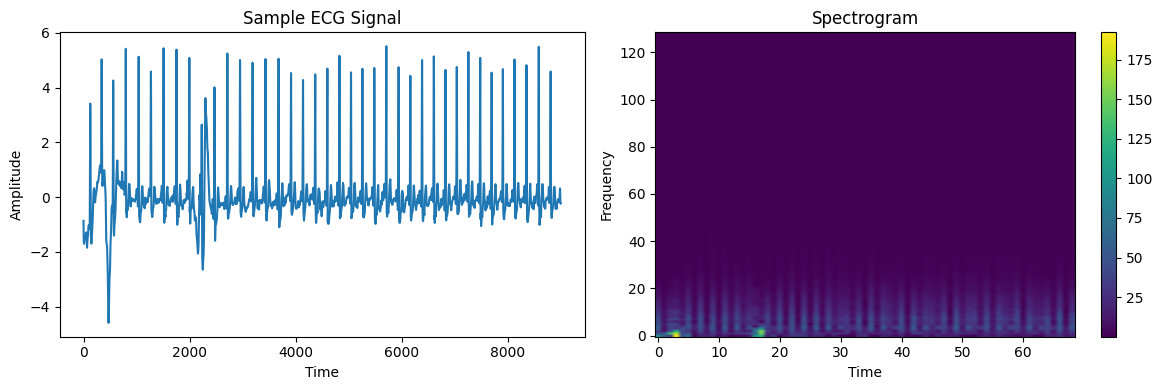

In [6]:
# ============================================================================
# CELL 5: Generate Spectrograms using FFT
# ============================================================================
def compute_spectrogram(signal, n_fft=256, hop_length=128):
    """
    Compute spectrogram using Short-Time Fourier Transform (STFT)

    Args:
        signal: 1D ECG signal
        n_fft: FFT window size
        hop_length: Number of samples between successive frames

    Returns:
        Spectrogram magnitude (2D array)
    """
    # Compute STFT
    stft = tf.signal.stft(
        signal,
        frame_length=n_fft,
        frame_step=hop_length,
        fft_length=n_fft
    )

    # Get magnitude
    spectrogram = tf.abs(stft)

    return spectrogram.numpy()

print("Computing spectrograms for training data...")
X_train_spec = np.array([compute_spectrogram(sig.squeeze()) for sig in X_train])
print("Computing spectrograms for validation data...")
X_val_spec = np.array([compute_spectrogram(sig.squeeze()) for sig in X_val])

# Add channel dimension for Conv2D
X_train_spec = X_train_spec[..., np.newaxis]
X_val_spec = X_val_spec[..., np.newaxis]

print(f"\nTrain spectrogram shape: {X_train_spec.shape}")
print(f"Val spectrogram shape: {X_val_spec.shape}")

# Visualize sample spectrogram
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train[0].squeeze())
plt.title("Sample ECG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.imshow(X_train_spec[0].squeeze().T, aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.tight_layout()
plt.show()

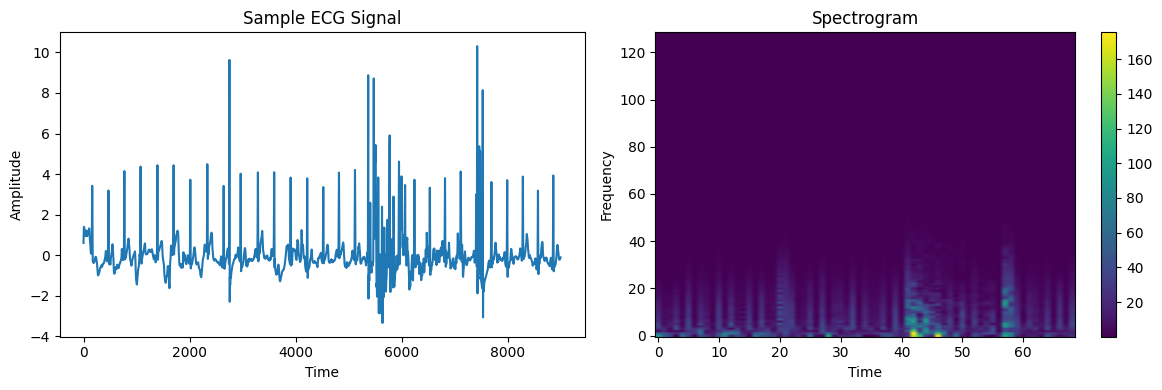

In [7]:
# Visualize sample spectrogram
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train[1].squeeze())
plt.title("Sample ECG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.imshow(X_train_spec[1].squeeze().T, aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.tight_layout()
plt.show()

# Log-scaled STFT

In [9]:
def compute_log_spectrogram(signal, n_fft=256, hop_length=128, eps=1e-6):
    stft = tf.signal.stft(
        signal,
        frame_length=n_fft,
        frame_step=hop_length,
        fft_length=n_fft,
        window_fn=tf.signal.hann_window
    )
    magnitude = tf.abs(stft)
    log_spec = tf.math.log(magnitude + eps)
    return log_spec.numpy()


In [10]:
X_train_spec = np.array([compute_log_spectrogram(sig.squeeze()) for sig in X_train])
X_val_spec   = np.array([compute_log_spectrogram(sig.squeeze()) for sig in X_val])

X_train_spec = X_train_spec[..., np.newaxis]
X_val_spec   = X_val_spec[..., np.newaxis]


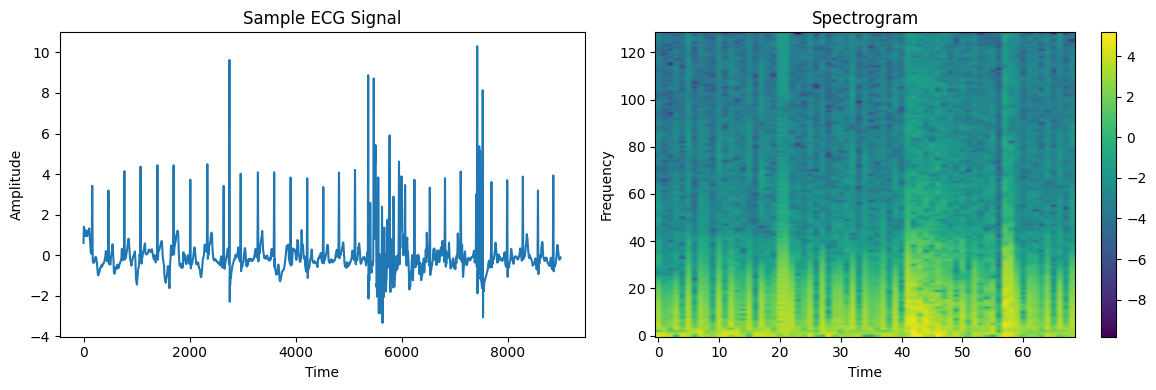

In [11]:
# Visualize sample spectrogram
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train[1].squeeze())
plt.title("Sample ECG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.imshow(X_train_spec[1].squeeze().T, aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.tight_layout()
plt.show()

# Frequency cropping (ECG-specific)

In [12]:
def crop_freq(spec, fs, max_freq=50):
    freq_bins = spec.shape[1]
    max_bin = int((max_freq / (fs / 2)) * freq_bins)
    return spec[:, :max_bin]


In [13]:
fs = 300  # example sampling rate
X_train_spec = np.array([crop_freq(s, fs) for s in X_train_spec.squeeze()])
X_train_spec = X_train_spec[..., np.newaxis]


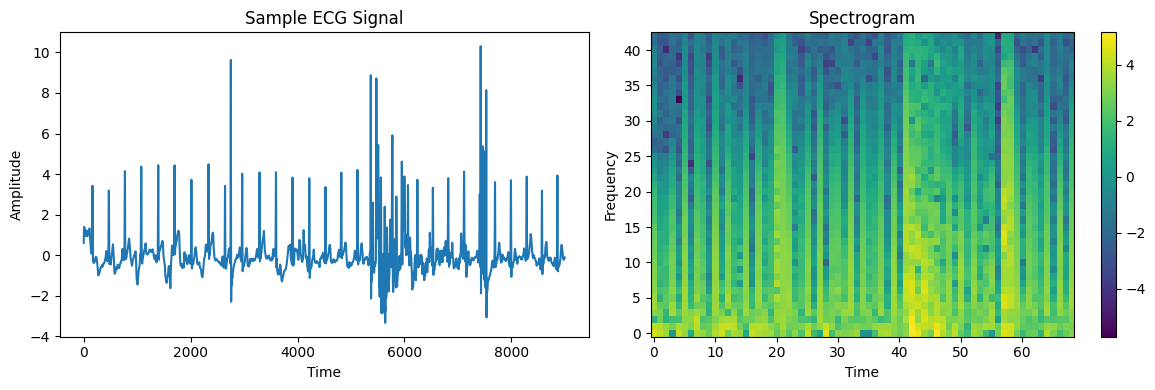

In [14]:
# Visualize sample spectrogram
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train[1].squeeze())
plt.title("Sample ECG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.imshow(X_train_spec[1].squeeze().T, aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.tight_layout()
plt.show()

# Mel-scaled Spectrogram

In [20]:
def compute_mel_spectrogram(signal, fs=300, n_fft=256, hop_length=128, n_mels=64):
    signal = tf.convert_to_tensor(signal, dtype=tf.float32)

    stft = tf.signal.stft(
        signal,
        frame_length=n_fft,
        frame_step=hop_length,
        fft_length=n_fft,
        window_fn=tf.signal.hann_window
    )

    spectrogram = tf.abs(stft)

    mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=n_mels,
        num_spectrogram_bins=n_fft // 2 + 1,
        sample_rate=fs,
        lower_edge_hertz=0.0,
        upper_edge_hertz=50.0,
        dtype=tf.float32
    )

    mel_spec = tf.tensordot(spectrogram, mel_filterbank, axes=1)
    mel_spec = tf.math.log(mel_spec + 1e-6)

    return mel_spec.numpy()


In [21]:
X_train_mel = np.array([
    compute_mel_spectrogram(sig.squeeze()) 
    for sig in X_train
])

X_train_mel = X_train_mel[..., np.newaxis]

print(X_train_mel.shape)
print(X_train_mel.dtype)


(7510, 69, 64, 1)
float32


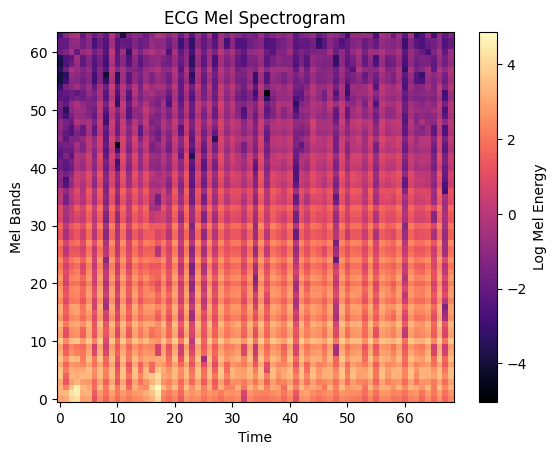

In [22]:
plt.imshow(
    X_train_mel[0].squeeze().T,
    aspect='auto',
    origin='lower',
    cmap='magma'
)
plt.colorbar(label="Log Mel Energy")
plt.xlabel("Time")
plt.ylabel("Mel Bands")
plt.title("ECG Mel Spectrogram")
plt.show()


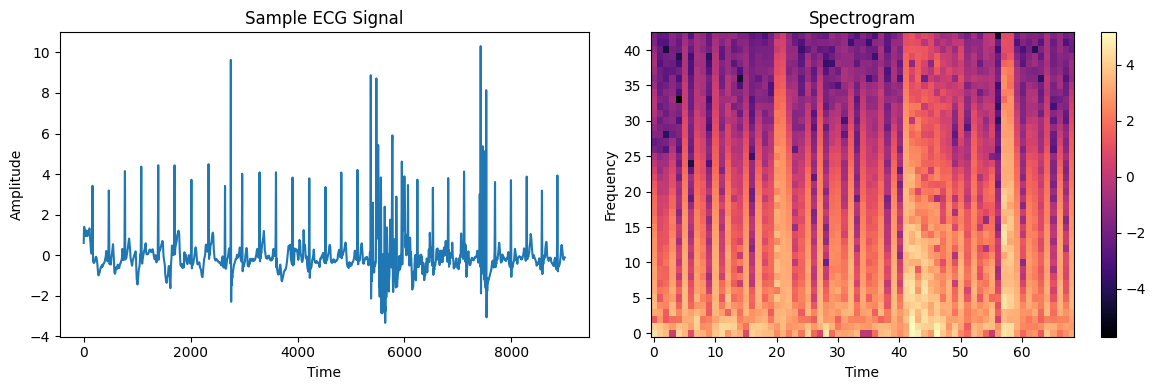

In [23]:
# Visualize sample spectrogram
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train[1].squeeze())
plt.title("Sample ECG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.imshow(X_train_spec[1].squeeze().T, aspect='auto', origin='lower', cmap='magma')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.tight_layout()
plt.show()

# Continuous Wavelet Transform

In [24]:
pip install pywavelets


Note: you may need to restart the kernel to use updated packages.


In [25]:
import pywt
import numpy as np

def compute_cwt(signal, fs=300, scales=np.arange(1, 128)):
    """
    Continuous Wavelet Transform using Morlet wavelet

    Args:
        signal: 1D ECG signal
        fs: sampling frequency
        scales: wavelet scales

    Returns:
        |CWT| magnitude (2D array)
    """
    signal = np.asarray(signal, dtype=np.float32)

    cwt_coeffs, freqs = pywt.cwt(
        signal,
        scales=scales,
        wavelet='morl',
        sampling_period=1/fs
    )

    return np.abs(cwt_coeffs)


In [ ]:
X_train_cwt = np.array([
    compute_cwt(sig.squeeze()) 
    for sig in X_train
])

X_train_cwt = X_train_cwt[..., np.newaxis]


In [ ]:
plt.imshow(
    X_train_cwt[0].squeeze(),
    aspect='auto',
    origin='lower',
    cmap='magma'
)
plt.colorbar(label="CWT Magnitude")
plt.xlabel("Time")
plt.ylabel("Scales")
plt.title("ECG CWT (Morlet)")
plt.show()


# Better visualization

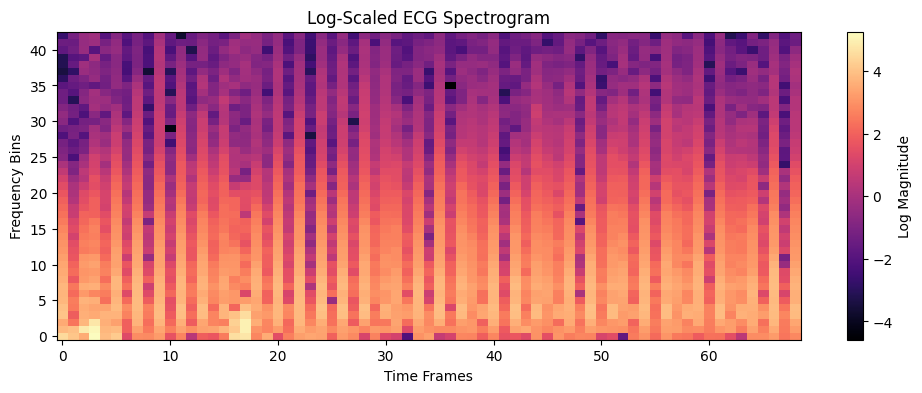

In [19]:
plt.figure(figsize=(12, 4))
plt.imshow(
    X_train_spec[0].squeeze().T,
    aspect='auto',
    origin='lower',
    cmap='magma'
)
plt.colorbar(label="Log Magnitude")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.title("Log-Scaled ECG Spectrogram")
plt.show()
